In [1]:
# Week 3 – Unsupervised Learning and Clustering Analysis

## Virtual Data Science with Python Trainee

'''Dataset: Mall Customers
Algorithm: K-Means Clustering'''

'Dataset: Mall Customers\nAlgorithm: K-Means Clustering'

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/abcom-mltutorials/mall/main/Mall_Customers.csv"

df = pd.read_csv(url)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (200, 5)


In [4]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [6]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [7]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [8]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [9]:
X = df[["Annual Income (k$)", "Spending Score (1-100)"]]

print("Features selected for clustering:")
print(X.head())

Features selected for clustering:
   Annual Income (k$)  Spending Score (1-100)
0                  15                      39
1                  15                      81
2                  16                       6
3                  16                      77
4                  17                      40


In [10]:
print("Shape of clustering data:", X.shape)

Shape of clustering data: (200, 2)


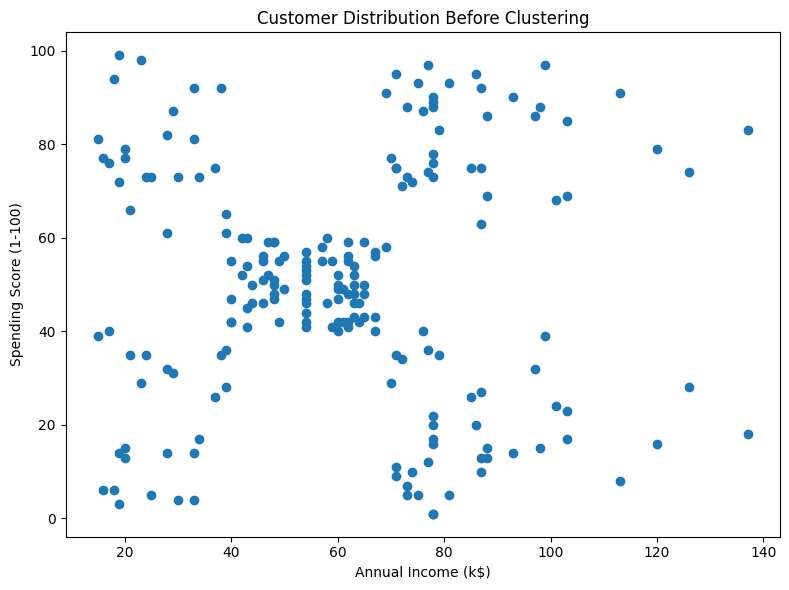

In [11]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X["Annual Income (k$)"],
    X["Spending Score (1-100)"]
)

plt.title("Customer Distribution Before Clustering")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")

plt.tight_layout()
plt.show()

In [12]:
from sklearn.cluster import KMeans

In [13]:
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

print(wcss)

[269981.28000000014, 181363.59595959607, 106348.37306211119, 73679.78903948837, 44448.45544793369, 37233.81451071002, 30241.34361793659, 25036.417604033977, 21916.79478984372, 20072.070939404]


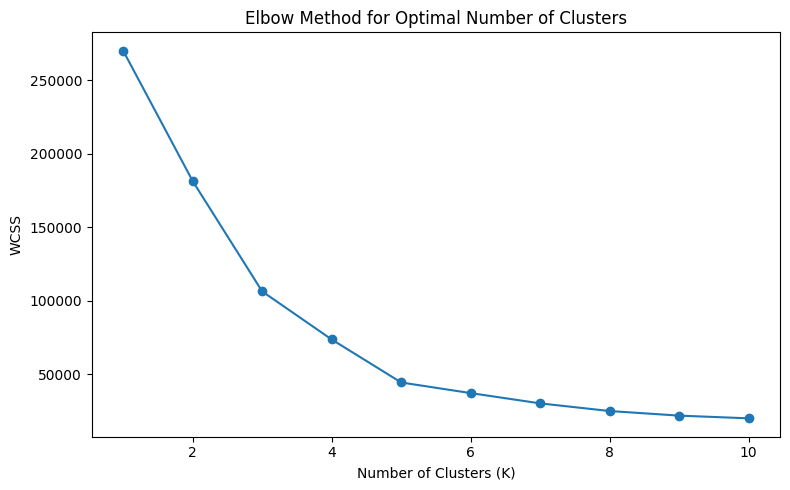

In [14]:
plt.figure(figsize=(8, 5))

plt.plot(range(1, 11), wcss, marker="o")

plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")

plt.tight_layout()
plt.show()

In [15]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)

print(silhouette_scores)

[np.float64(0.2968969162503008), np.float64(0.46761358158775435), np.float64(0.4931963109249047), np.float64(0.553931997444648), np.float64(0.53976103063432), np.float64(0.5288104473798049), np.float64(0.45481197931195283), np.float64(0.4561091950997367), np.float64(0.4410568674364981)]


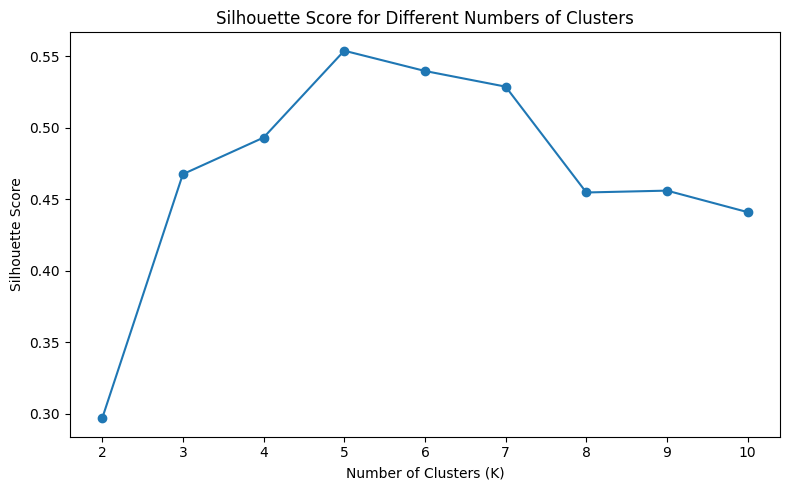

In [16]:
plt.figure(figsize=(8, 5))

plt.plot(range(2, 11), silhouette_scores, marker="o")

plt.title("Silhouette Score for Different Numbers of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")

plt.tight_layout()
plt.show()

In [17]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)

df["Cluster"] = kmeans.fit_predict(X)

print("K-Means clustering completed!")
print(df["Cluster"].value_counts().sort_index())

K-Means clustering completed!
Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64


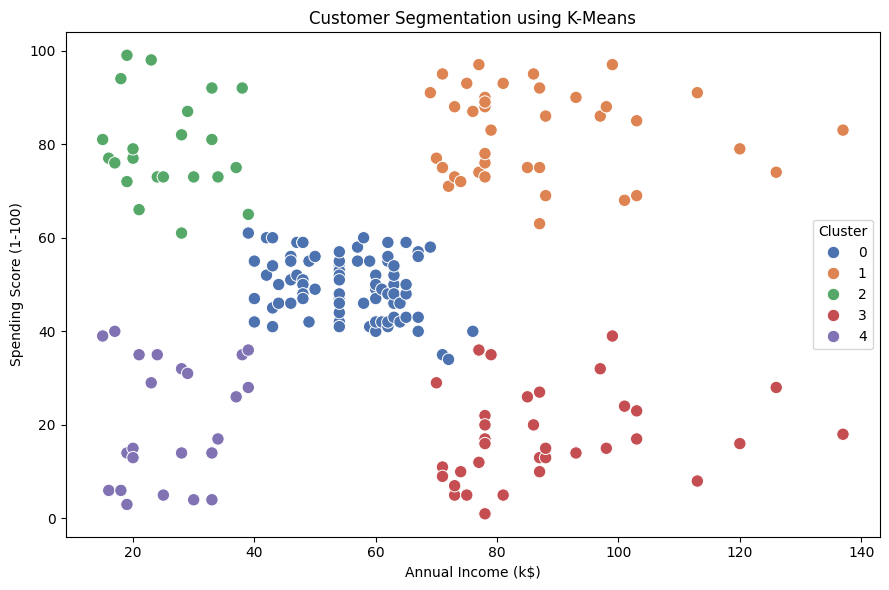

In [18]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Cluster",
    palette="deep",
    s=80
)

plt.title("Customer Segmentation using K-Means")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend(title="Cluster")

plt.tight_layout()
plt.show()

In [19]:
cluster_summary = df.groupby("Cluster").agg(
    Number_of_Customers=("CustomerID", "count"),
    Average_Age=("Age", "mean"),
    Average_Income=("Annual Income (k$)", "mean"),
    Average_Spending=("Spending Score (1-100)", "mean")
)

print(cluster_summary.round(2))

         Number_of_Customers  Average_Age  Average_Income  Average_Spending
Cluster                                                                    
0                         81        42.72           55.30             49.52
1                         39        32.69           86.54             82.13
2                         22        25.27           25.73             79.36
3                         35        41.11           88.20             17.11
4                         23        45.22           26.30             20.91


In [20]:
for cluster in sorted(df["Cluster"].unique()):
    print(f"\nCluster {cluster}")
    print(df[df["Cluster"] == cluster][
        ["Age", "Annual Income (k$)", "Spending Score (1-100)"]
    ].describe().round(2))


Cluster 0
         Age  Annual Income (k$)  Spending Score (1-100)
count  81.00               81.00                   81.00
mean   42.72               55.30                   49.52
std    16.45                8.99                    6.53
min    18.00               39.00                   34.00
25%    27.00               48.00                   44.00
50%    46.00               54.00                   50.00
75%    54.00               62.00                   55.00
max    70.00               76.00                   61.00

Cluster 1
         Age  Annual Income (k$)  Spending Score (1-100)
count  39.00               39.00                   39.00
mean   32.69               86.54                   82.13
std     3.73               16.31                    9.36
min    27.00               69.00                   63.00
25%    30.00               75.50                   74.50
50%    32.00               79.00                   83.00
75%    35.50               95.00                   90.00
max    40

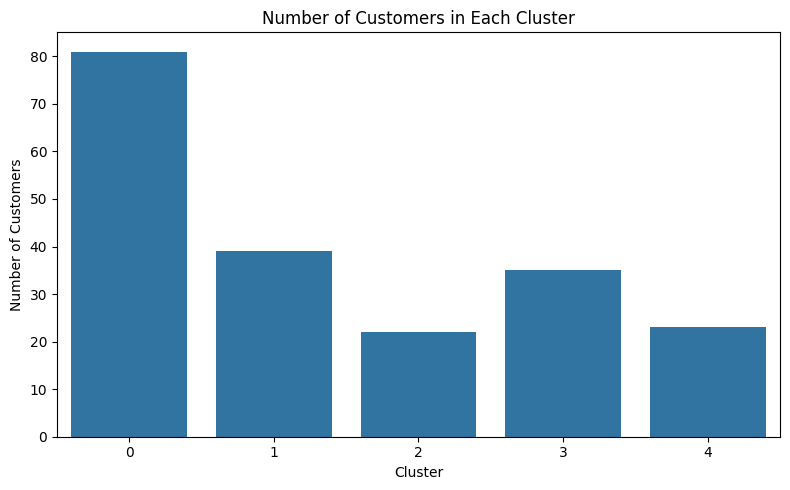

In [21]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="Cluster")

plt.title("Number of Customers in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

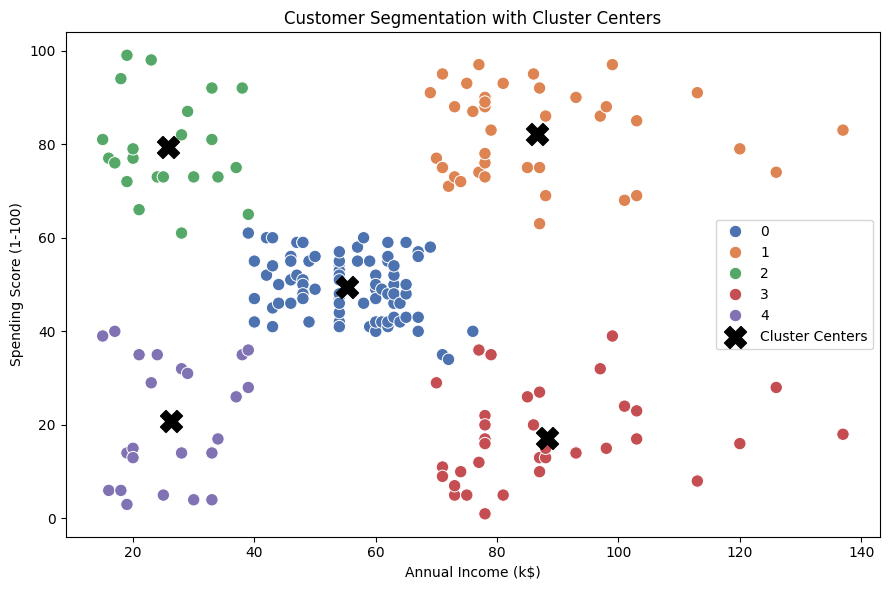

In [22]:
centers = kmeans.cluster_centers_

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Cluster",
    palette="deep",
    s=80
)

plt.scatter(
    centers[:, 0],
    centers[:, 1],
    marker="X",
    s=250,
    color="black",
    label="Cluster Centers"
)

plt.title("Customer Segmentation with Cluster Centers")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend()

plt.tight_layout()
plt.show()

In [23]:
cluster_summary = df.groupby("Cluster").agg(
    Number_of_Customers=("CustomerID", "count"),
    Average_Age=("Age", "mean"),
    Average_Income=("Annual Income (k$)", "mean"),
    Average_Spending=("Spending Score (1-100)", "mean")
).round(2)

cluster_summary

,Number_of_Customers,Average_Age,Average_Income,Average_Spending
Cluster,,,,
0,81,42.72,55.30,49.52
1,39,32.69,86.54,82.13
2,22,25.27,25.73,79.36
3,35,41.11,88.20,17.11
4,23,45.22,26.30,20.91
